# QuSpin ZXZ Y defects

Created: 08-06-2026

Objectives:

We want to implement Kyle's algorithm for finding defect operators. That is
1. Find $\rho$.
2. Take a purification of $\rho$, $\rho=\sum_i \lambda_i \ket{\psi_i} \bra{\psi_i}$.
3. Find defect operators on $\ket{\psi_i}$.

We will use a Hamiltonian of the form $\sum_i (-t*Z_{i-1}X_i Z_{i+1} -(1-t)*Y)$ to test this, which has an $XK$ time reversal symmetry.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

# Analysis

## Find grounstates

In [5]:
num_sites = 16

In [6]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [7]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=10):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [8]:
# Reduced number of parameter points from 201 to 11 when running on laptop.
parameters = np.linspace(0,1,11)

In [9]:
hamiltoniains = [
    get_hamiltoniain(t, 16)
    for t in parameters
]

In [10]:
energies = list()
groundstates = list()

for h in tqdm(hamiltoniains):
    e, psi = h.eigsh(k=1, which='SA')
    energies.append(e[0])
    groundstates.append(psi[:, 0])

100%|████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:04<00:00,  2.33it/s]


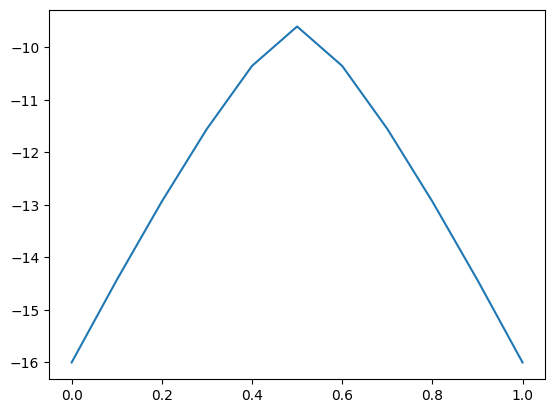

In [11]:
plt.plot(parameters, energies)

In [12]:
energies = np.array(energies)
parameters = np.array(parameters)

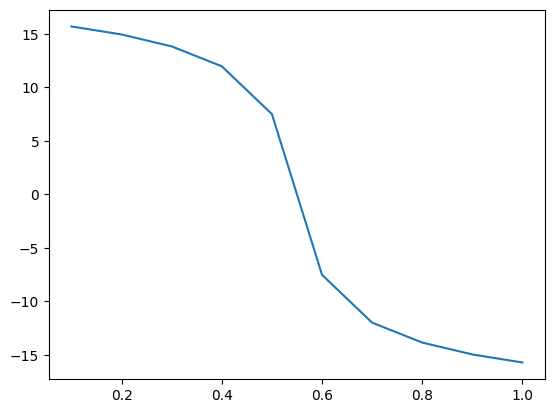

In [13]:
plt.plot(parameters[1:], (energies[1:] - energies[:-1])/(parameters[1]- parameters[0]))

## Expectations and correlation lengths

In [14]:
num_sites = 16
middle_site = num_sites//2

In [15]:
y_middle_site_op = quantum_operator(
    {"y": [["y", [[1, middle_site]]]]},
    basis=spin_basis_1d(num_sites, S="1/2", pauli=-1),
    dtype=np.complex128
)

Hermiticity check passed!
Symmetry checks passed!


In [16]:
y_middle_site_op.expt_value(groundstates[0])

np.complex128(0.9999999999999981-7.927451975872636e-22j)

In [17]:
y_middle_site_exps = [
    y_middle_site_op.expt_value(psi)
    for psi in groundstates
]

/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


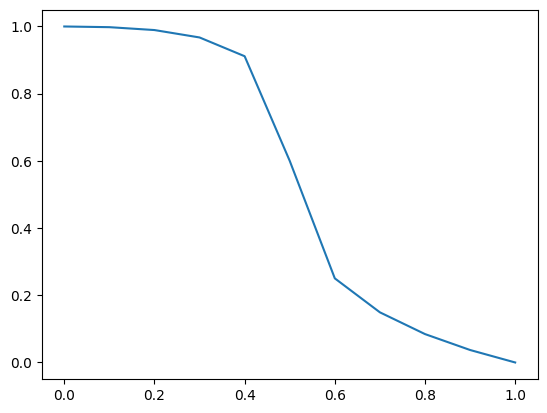

In [18]:
plt.plot(parameters, y_middle_site_exps)

In [19]:
y_site_ops = [
    quantum_operator(
        {"y": [["y", [[1, i]]]]},
        basis=spin_basis_1d(num_sites, S="1/2", pauli=-1),
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )
    for i in range(num_sites)
]

In [20]:
y_site_exps = [
    [op.expt_value(psi) for psi in groundstates]
    for op in y_site_ops
]

In [21]:
y_site_exps = np.array(y_site_exps)

In [22]:
y_site_exps.shape

(16, 11)

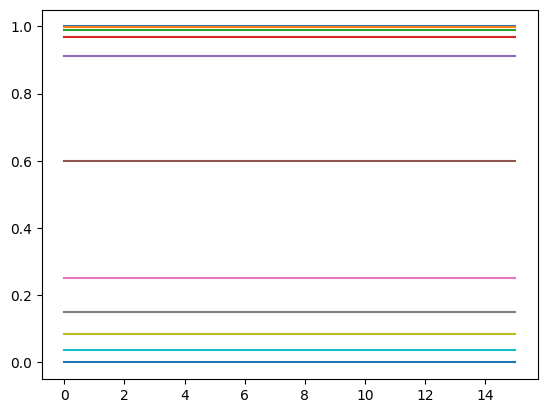

In [23]:
plt.plot(y_site_exps);

In [24]:
y_two_site_ops = [
    quantum_operator(
        {"y": [["yy", [[1, 0, i]]]]},
        basis=spin_basis_1d(num_sites, S="1/2", pauli=-1),
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )
    for i in range(num_sites//2)
]

In [25]:
y_two_site_exps = [
    [op.expt_value(psi) for psi in groundstates]
    for op in y_two_site_ops
]

y_two_site_exps = np.array(y_two_site_exps)

In [26]:
y_two_site_exps.shape

(8, 11)

In [27]:
y_two_site_exps.shape

(8, 11)

In [28]:
(y_two_site_exps[0]*y_two_site_exps[:(num_sites//2)]).shape

(8, 11)

In [29]:
y_correlations = (
    y_two_site_exps
    -(y_site_exps[0]*y_site_exps[:(num_sites//2)])
)

/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


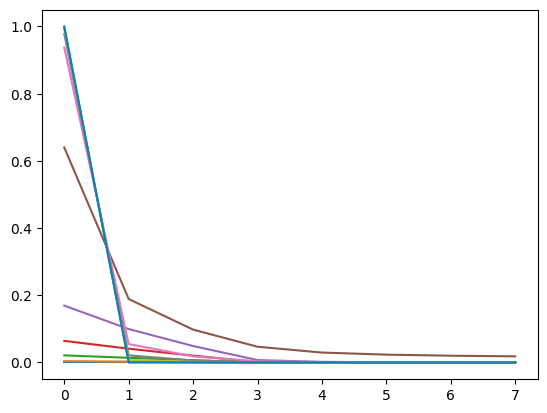

In [30]:
plt.plot(y_correlations);

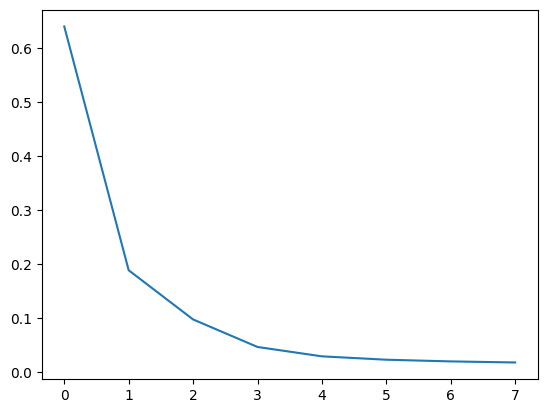

In [31]:
plt.plot(y_correlations[:,5]);

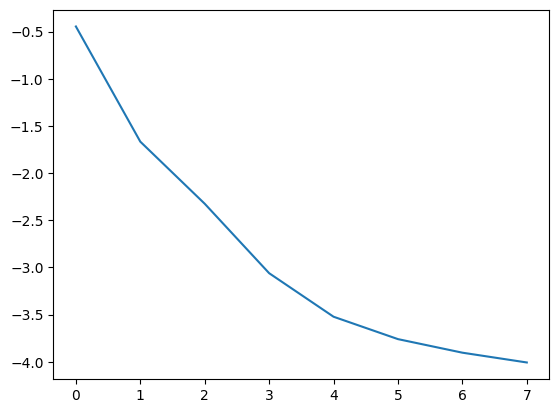

In [32]:
plt.plot(np.log(y_correlations[:,5]))

In [33]:
-6/np.log(y_correlations[5,10]/y_correlations[0,10])

np.complex128(0.15066297498086023+0.011515397911454483j)

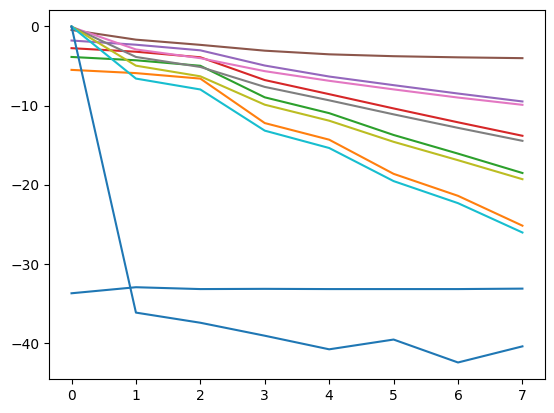

In [34]:
plt.plot(np.log(y_correlations));

In [35]:
y_correlations.shape

(8, 11)

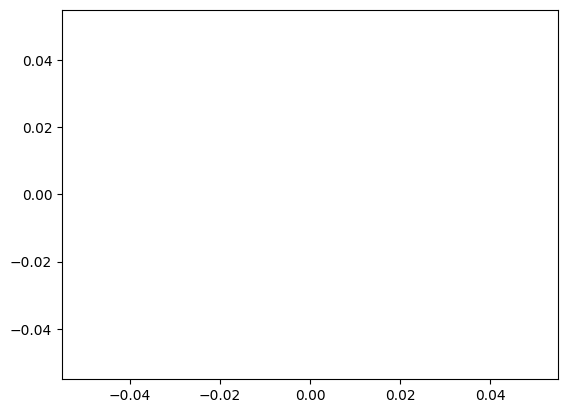

In [36]:
plt.plot(np.log(y_correlations[:, 60:80]));

In [37]:
corr_legnths = -4/np.log(y_correlations[4]/y_correlations[0])

In [38]:
corr_legnths[0]=0

In [39]:
corr_lengths = np.real(corr_legnths)

In [40]:
corr_lengths = np.nan_to_num(corr_legnths, nan=0)

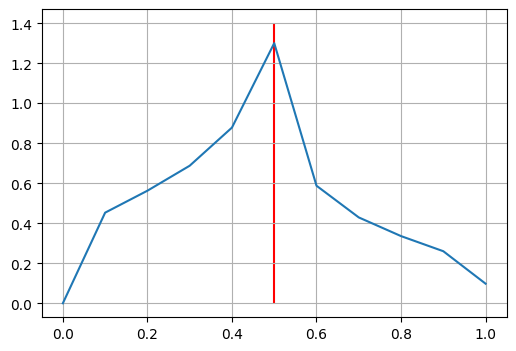

In [41]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(parameters, corr_legnths)
ax.vlines(0.5, ymin=0, ymax=(1.4), color='red', zorder=-1)
ax.grid()

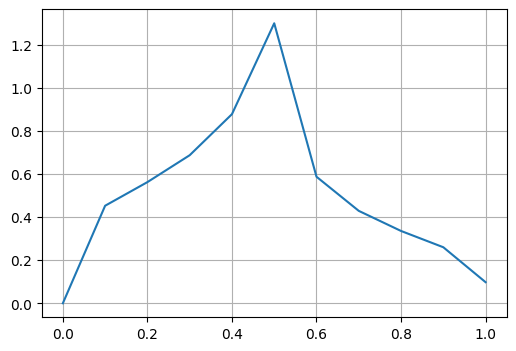

In [42]:
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(parameters[:20], corr_legnths[:20])
#ax.vlines(0.5, ymin=0, ymax=(1.4), color='red', zorder=-1)
ax.grid()

What's going on with these correlation lengths?

## Check properties of cut states

In [43]:
psi = groundstates[8]

In [44]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [45]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [46]:
rho = basis.partial_trace(
    psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

In [47]:
num_sites

16

In [48]:
num_symmetry_sites

8

In [49]:
rho.shape

(256, 256)

In [50]:
eigenvalues, eigenvectors = np.linalg.eigh(rho)

In [51]:
np.round(eigenvalues[-10:], 3)

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.25, 0.25, 0.25, 0.25])

In [52]:
psi_0 = eigenvectors[:, -1]

In [53]:
np.dot(psi_0.conj(), psi_0)

np.complex128(0.9999999999999997+0j)

In [54]:
rho.shape

(256, 256)

In [55]:
psi_0.shape

(256,)

In [56]:
np.linalg.norm((4*(rho @ psi_0)) - psi_0)

np.float64(9.792412371636195e-05)

So it is an eigenvector

In [57]:
proj_psis = [
    eigenvectors[:, -i]
    for i in range(1, 5)
]

In [58]:
len(proj_psis)

4

In [60]:
rdm_basis = spin_basis_1d(num_symmetry_sites, S="1/2", pauli=-1)

In [61]:
proj_rho_lrs = [
    rdm_basis.partial_trace(
        proj_psi,
        sub_sys_A=[0,1, 6,7],
        return_rdm="A",
        enforce_pure=True
    )
    for proj_psi in proj_psis
]

In [62]:
proj_rho_lrs[0].shape

(16, 16)

In [63]:
sum_proj_rho_lrs = 0.25*sum(proj_rho_lrs)

In [64]:
sum_proj_rho_lrs.shape

(16, 16)

In [65]:
np.trace(sum_proj_rho_lrs)

np.complex128(1-4.2582136393708423e-19j)

In [66]:
rho_lr = np.reshape(sum_proj_rho_lrs, (4,4,4,4), order='F')

In [67]:
rho_lr = np.transpose(rho_lr, [0,2,1,3])

In [68]:
rho_lr = np.reshape(rho_lr, (16, 16), order='F')

In [69]:
u, s, vh = np.linalg.svd(rho_lr)

In [70]:
s

array([2.53622458e-01, 3.47480724e-03, 4.18065600e-04, 4.18019154e-04,
       9.55052621e-06, 9.49093067e-06, 3.48381230e-06, 2.06843740e-06,
       1.21336949e-07, 1.08374634e-07, 1.03268338e-07, 2.88849722e-08,
       7.81337779e-09, 6.52902594e-09, 2.28972842e-10, 1.57555258e-10])

In [71]:
len(proj_rho_lrs)

4

In [72]:
X = np.arange(16)

In [73]:
X

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [74]:
X.reshape((2,2,2,2))

array([[[[ 0,  1],
         [ 2,  3]],

        [[ 4,  5],
         [ 6,  7]]],


       [[[ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15]]]])

In [75]:
print(spin_basis_1d(4, S="1/2", pauli=-1))

reference states: 
array index   /   Fock state   /   integer repr. 
  0.  |1 1 1 1>  15 
  1.  |1 1 1 0>  14 
  2.  |1 1 0 1>  13 
  3.  |1 1 0 0>  12 
  4.  |1 0 1 1>  11 
  5.  |1 0 1 0>  10 
  6.  |1 0 0 1>   9 
  7.  |1 0 0 0>   8 
  8.  |0 1 1 1>   7 
  9.  |0 1 1 0>   6 
 10.  |0 1 0 1>   5 
 11.  |0 1 0 0>   4 
 12.  |0 0 1 1>   3 
 13.  |0 0 1 0>   2 
 14.  |0 0 0 1>   1 
 15.  |0 0 0 0>   0 


In [76]:
left_right_proj_schmidt_vals = list()

for proj_rho_lr in proj_rho_lrs:
    rho_lr = np.reshape(proj_rho_lr, (4,4,4,4))
    rho_lr = np.transpose(rho_lr, [0,2,1,3])
    rho_lr = np.reshape(rho_lr, (16, 16))
    u, s, vh = np.linalg.svd(rho_lr)

    left_right_proj_schmidt_vals.append(s)

In [77]:
len(left_right_proj_schmidt_vals)

4

In [78]:
left_right_proj_schmidt_vals

[array([0.25364844, 0.24995156, 0.24913548, 0.24724369, 0.00363439,
        0.00358358, 0.00354784, 0.00347328, 0.00040764, 0.00039447,
        0.00039265, 0.00039072, 0.0003896 , 0.00038863, 0.00038712,
        0.00037967]),
 array([0.25362269, 0.2499365 , 0.24820084, 0.2481995 , 0.00358334,
        0.00356938, 0.00355381, 0.00347322, 0.0004013 , 0.00039685,
        0.00039362, 0.00039359, 0.00039064, 0.0003893 , 0.00038597,
        0.00038567]),
 array([0.25361398, 0.24996791, 0.24992072, 0.24646443, 0.00361453,
        0.00357655, 0.00351607, 0.00347327, 0.00040029, 0.00039796,
        0.00039532, 0.00039261, 0.00039191, 0.00038836, 0.00038677,
        0.00038384]),
 array([0.25360566, 0.24993476, 0.24899583, 0.24741451, 0.00356779,
        0.00355363, 0.00352591, 0.00347312, 0.00040402, 0.00039532,
        0.00039445, 0.00039289, 0.00039124, 0.0003907 , 0.0003894 ,
        0.00038589])]

Check Y correlations

In [79]:
y_site_ops = [
    quantum_operator(
        {"y": [["y", [[1, i]]]]},
        basis=spin_basis_1d(num_symmetry_sites, S="1/2", pauli=-1),
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )
    for i in range(num_symmetry_sites)
]

In [80]:
y_site_exps = np.array([
    op.expt_value(psi_0)
    for op in y_site_ops
])

In [81]:
y_site_exps = np.real(y_site_exps)

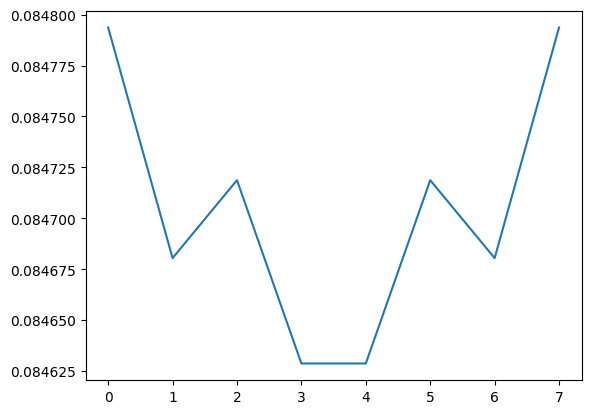

In [82]:
plt.plot(y_site_exps)

In [83]:
y_two_site_ops = [
    [
        quantum_operator(
            {"y": [["yy", [[1, i, j]]]]},
            basis=spin_basis_1d(num_symmetry_sites, S="1/2", pauli=-1),
            dtype=np.complex128,
            check_symm=False,
            check_herm=False
        )
        for j in range(num_symmetry_sites)
    ]
    for i in range(num_symmetry_sites)
]

In [84]:
y_two_site_exps = [
    [op.expt_value(psi_0) for op in l]
    for l in y_two_site_ops
]

y_two_site_exps = np.array(y_two_site_exps)

In [85]:
y_two_site_exps = np.real(y_two_site_exps)

In [86]:
y_correlations = y_two_site_exps - y_site_exps[:, np.newaxis]*y_site_exps[np.newaxis, :]

In [87]:
np.round(y_correlations, 3)

array([[0.993, 0.007, 0.003, 0.001, 0.   , 0.001, 0.001, 0.   ],
       [0.007, 0.993, 0.008, 0.002, 0.001, 0.001, 0.   , 0.001],
       [0.003, 0.008, 0.993, 0.008, 0.002, 0.001, 0.001, 0.001],
       [0.001, 0.002, 0.008, 0.993, 0.007, 0.002, 0.001, 0.   ],
       [0.   , 0.001, 0.002, 0.007, 0.993, 0.008, 0.002, 0.001],
       [0.001, 0.001, 0.001, 0.002, 0.008, 0.993, 0.008, 0.003],
       [0.001, 0.   , 0.001, 0.001, 0.002, 0.008, 0.993, 0.007],
       [0.   , 0.001, 0.001, 0.   , 0.001, 0.003, 0.007, 0.993]])

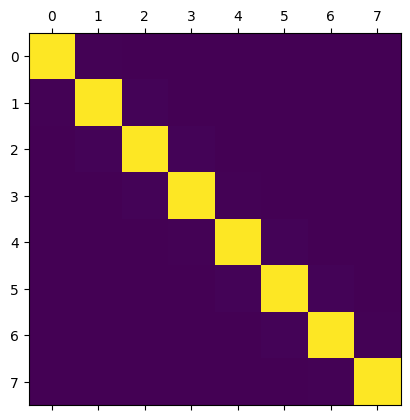

In [88]:
plt.matshow(y_correlations)

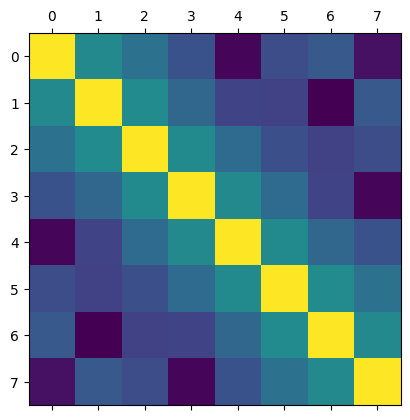

In [89]:
plt.matshow(np.log(y_correlations))

Pretty much what we expect. There are some small edge to edge correlations.

In [90]:
rdm_basis = spin_basis_1d(num_symmetry_sites, S="1/2", pauli=-1)

In [91]:
rho_lr = basis.partial_trace(
    psi,
    sub_sys_A=[0,1, 6,7],
    return_rdm="A",
    enforce_pure=True
)

In [92]:
rho_lr.shape

(16, 16)

In [93]:
rho_lr = np.reshape(rho_lr, (4,4,4,4), order='F')

In [94]:
rho_lr = np.transpose(rho_lr, [0,2,1,3])

In [95]:
rho_lr = np.reshape(rho_lr, (16, 16), order='F')

In [96]:
u, s, vh = np.linalg.svd(rho_lr)

In [97]:
s

array([2.53622466e-01, 3.47459909e-03, 4.18726568e-04, 4.18498930e-04,
       9.93992092e-06, 9.77264808e-06, 3.48348535e-06, 2.02785357e-06,
       2.93888598e-07, 2.65754816e-07, 1.22740468e-07, 3.61606826e-08,
       3.11492880e-08, 1.55393458e-08, 1.53619094e-08, 1.75247657e-09])

In [100]:
rho_lr = rdm_basis.partial_trace(
    psi_0,
    sub_sys_A=[0,1, 6,7],
    return_rdm="A",
    enforce_pure=True
)

In [101]:
rho_lr.shape

(16, 16)

In [102]:
defect_basis = spin_basis_1d(4, S="1/2", pauli=-1)

In [103]:
print(defect_basis)

reference states: 
array index   /   Fock state   /   integer repr. 
  0.  |1 1 1 1>  15 
  1.  |1 1 1 0>  14 
  2.  |1 1 0 1>  13 
  3.  |1 1 0 0>  12 
  4.  |1 0 1 1>  11 
  5.  |1 0 1 0>  10 
  6.  |1 0 0 1>   9 
  7.  |1 0 0 0>   8 
  8.  |0 1 1 1>   7 
  9.  |0 1 1 0>   6 
 10.  |0 1 0 1>   5 
 11.  |0 1 0 0>   4 
 12.  |0 0 1 1>   3 
 13.  |0 0 1 0>   2 
 14.  |0 0 0 1>   1 
 15.  |0 0 0 0>   0 


In [104]:
rho_lr = np.reshape(rho_lr, (4,4,4,4), order='F')

In [105]:
rho_lr = np.transpose(rho_lr, [0,2,1,3])

In [106]:
rho_lr = np.reshape(rho_lr, (16, 16), order='F')

In [107]:
u, s, vh = np.linalg.svd(rho_lr)

In [108]:
s

array([0.25364844, 0.24995156, 0.24913548, 0.24724369, 0.00363439,
       0.00358358, 0.00354784, 0.00347328, 0.00040764, 0.00039447,
       0.00039265, 0.00039072, 0.0003896 , 0.00038863, 0.00038712,
       0.00037967])

In [109]:
rho_lr = rdm_basis.partial_trace(
    psi_0,
    sub_sys_A=[0,1, 6,7],
    return_rdm="A",
    enforce_pure=True
)

In [110]:
rho_lr.shape

(16, 16)

In [111]:
np_Y = np.array([
    [0, -1j],
    [1j, 0]
])

np_I = np.eye(2)

In [112]:
help(reduce)

Help on built-in function reduce in module _functools:

reduce(...)
    reduce(function, iterable[, initial]) -> value
    
    Apply a function of two arguments cumulatively to the items of a sequence
    or iterable, from left to right, so as to reduce the iterable to a single
    value.  For example, reduce(lambda x, y: x+y, [1, 2, 3, 4, 5]) calculates
    ((((1+2)+3)+4)+5).  If initial is present, it is placed before the items
    of the iterable in the calculation, and serves as a default when the
    iterable is empty.



In [113]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [114]:
np_Y_0 = multikron([np_Y, np_I, np_I, np_I])
np_Y_1 = multikron([np_I, np_Y, np_I, np_I])
np_Y_2 = multikron([np_I, np_I, np_Y, np_I])
np_Y_3 = multikron([np_I, np_I, np_I, np_Y])

In [115]:
np_Y_0.shape

(16, 16)

In [116]:
(
    np.trace(rho_lr @ np_Y_0),
    np.trace(rho_lr @ np_Y_1),
    np.trace(rho_lr @ np_Y_2),
    np.trace(rho_lr @ np_Y_3)
)

(np.complex128(0.08479370725269215+0j),
 np.complex128(0.08468043160386157+0j),
 np.complex128(0.08468043160386216+0j),
 np.complex128(0.08479370725269134+0j))

In [117]:
y_site_exps

array([0.08479371, 0.08468043, 0.08471871, 0.08462868, 0.08462868,
       0.08471871, 0.08468043, 0.08479371])

Agree.

In [118]:
rho_lr = np.reshape(rho_lr, (4,4,4,4))

In [119]:
np_Y_0 = np.reshape(np_Y_0, (4,4,4,4))
np_Y_1 = np.reshape(np_Y_1, (4,4,4,4))
np_Y_2 = np.reshape(np_Y_2, (4,4,4,4))
np_Y_3 = np.reshape(np_Y_3, (4,4,4,4))

In [120]:
(
    np.tensordot(rho_lr, np_Y_0, [[0,1,2,3], [2,3,0,1]]),
    np.tensordot(rho_lr, np_Y_1, [[0,1,2,3], [2,3,0,1]]),
    np.tensordot(rho_lr, np_Y_2, [[0,1,2,3], [2,3,0,1]]),
    np.tensordot(rho_lr, np_Y_3, [[0,1,2,3], [2,3,0,1]])
)

(array(0.08479371+0.j),
 array(0.08468043+0.j),
 array(0.08468043+0.j),
 array(0.08479371+0.j))

In [121]:
rho_lr = np.transpose(rho_lr, [0,2,1,3])

In [122]:
np_Y_0 = np.transpose(np_Y_0, [0,2,1,3])
np_Y_1 = np.transpose(np_Y_1, [0,2,1,3])
np_Y_2 = np.transpose(np_Y_2, [0,2,1,3])
np_Y_3 = np.transpose(np_Y_3, [0,2,1,3])

In [123]:
(
    np.tensordot(rho_lr, np_Y_0, [[0,1,2,3], [1,0,3,2]]),
    np.tensordot(rho_lr, np_Y_1, [[0,1,2,3], [1,0,3,2]]),
    np.tensordot(rho_lr, np_Y_2, [[0,1,2,3], [1,0,3,2]]),
    np.tensordot(rho_lr, np_Y_3, [[0,1,2,3], [1,0,3,2]])
)

(array(0.08479371+0.j),
 array(0.08468043+0.j),
 array(0.08468043+0.j),
 array(0.08479371+0.j))

In [124]:
rho_lr = np.reshape(rho_lr, (16, 16))

In [125]:
np_Y_0 = np.transpose(np_Y_0, [0,2,1,3])
np_Y_1 = np.transpose(np_Y_1, [0,2,1,3])
np_Y_2 = np.transpose(np_Y_2, [0,2,1,3])
np_Y_3 = np.transpose(np_Y_3, [0,2,1,3])

In [126]:
u, s, vh = np.linalg.svd(rho_lr)

In [127]:
s

array([0.25364844, 0.24995156, 0.24913548, 0.24724369, 0.00363439,
       0.00358358, 0.00354784, 0.00347328, 0.00040764, 0.00039447,
       0.00039265, 0.00039072, 0.0003896 , 0.00038863, 0.00038712,
       0.00037967])

Try other permutations of indices.

In [128]:
psi_0.shape

(256,)

In [129]:
rho_lr = rdm_basis.partial_trace(
    psi_0,
    sub_sys_A=[0,1, 6,7],
    return_rdm="A",
    enforce_pure=True
)

In [130]:
rho_lr = np.reshape(rho_lr, (4,4,4,4))

In [131]:
from itertools import permutations

In [132]:
schmidt_vals_perms = list()

for perm in permutations(list(range(4))):
    perm_rho_lr = np.transpose(rho_lr, perm)
    perm_rho_lr = np.reshape(perm_rho_lr, (16, 16))
    u, s, vh = np.linalg.svd(perm_rho_lr)

    schmidt_vals_perms.append(s)

In [133]:
schmidt_vals_perms = np.array(schmidt_vals_perms)

In [134]:
schmidt_vals_perms.shape

(24, 16)

In [135]:
np.round(schmidt_vals_perms[:, :8], 3)

array([[0.257, 0.25 , 0.247, 0.246, 0.   , 0.   , 0.   , 0.   ],
       [0.257, 0.25 , 0.247, 0.246, 0.   , 0.   , 0.   , 0.   ],
       [0.254, 0.25 , 0.249, 0.247, 0.004, 0.004, 0.004, 0.003],
       [0.254, 0.25 , 0.249, 0.247, 0.004, 0.004, 0.004, 0.003],
       [0.157, 0.146, 0.143, 0.134, 0.129, 0.125, 0.125, 0.125],
       [0.157, 0.146, 0.143, 0.134, 0.129, 0.125, 0.125, 0.125],
       [0.257, 0.25 , 0.247, 0.246, 0.   , 0.   , 0.   , 0.   ],
       [0.257, 0.25 , 0.247, 0.246, 0.   , 0.   , 0.   , 0.   ],
       [0.157, 0.146, 0.143, 0.134, 0.129, 0.125, 0.125, 0.125],
       [0.157, 0.146, 0.143, 0.134, 0.129, 0.125, 0.125, 0.125],
       [0.254, 0.25 , 0.249, 0.247, 0.004, 0.004, 0.004, 0.003],
       [0.254, 0.25 , 0.249, 0.247, 0.004, 0.004, 0.004, 0.003],
       [0.254, 0.25 , 0.249, 0.247, 0.004, 0.004, 0.004, 0.003],
       [0.254, 0.25 , 0.249, 0.247, 0.004, 0.004, 0.004, 0.003],
       [0.157, 0.146, 0.143, 0.134, 0.129, 0.125, 0.125, 0.125],
       [0.157, 0.146, 0.1

Entangled no matter how you make the cut.

### Extract MPS tensors

In [136]:
psi_0.shape

(256,)

In [137]:
psi_0_1 = np.reshape(psi_0, (2, -1))

In [138]:
u, s, vh = np.linalg.svd(psi_0_1, full_matrices=False)

In [139]:
s

array([0.73647604, 0.67646363])

In [140]:
u.shape

(2, 2)

In [141]:
vh.shape

(2, 128)

In [142]:
a_tensors = [u,]
schmidt_values = [s,]

In [143]:
psi_0_2 = np.reshape(vh, (4, -1))

In [144]:
u, s, vh = np.linalg.svd(psi_0_2, full_matrices=False)

In [145]:
s

array([0.73869697, 0.73375095, 0.6794185 , 0.67403771])

In [146]:
u.shape

(4, 4)

In [147]:
a_tensors.append(u.reshape(2,2,-1))

In [148]:
schmidt_values.append(s)

In [149]:
vh.shape

(4, 64)

In [150]:
psi_0_3 = np.reshape(vh, (8, -1))

In [151]:
u, s, vh = np.linalg.svd(psi_0_3, full_matrices=False)

In [152]:
u.shape

(8, 8)

In [153]:
a_tensors.append(u.reshape(4,2,-1))

In [154]:
s

array([1.0056558 , 1.00262913, 0.99734999, 0.99429784, 0.00452146,
       0.00449271, 0.00279905, 0.00275075])

In [155]:
schmidt_values.append(s)

In [156]:
vh.shape

(8, 32)

In [157]:
psi_0_4 = np.reshape(vh, (16, -1))

In [158]:
u, s, vh = np.linalg.svd(psi_0_4, full_matrices=False)

In [159]:
s

array([1.39878777e+00, 1.39824895e+00, 1.37651531e+00, 1.37577601e+00,
       3.34343164e-01, 3.14671870e-01, 2.13652614e-01, 2.02520445e-01,
       3.03405460e-02, 3.03178763e-02, 2.69129417e-02, 2.66179555e-02,
       4.07648248e-04, 3.23058227e-04, 2.14628705e-04, 2.07749508e-04])

In [160]:
u.shape

(16, 16)

In [161]:
a_tensors.append(u.reshape(8, 2, -1))

In [162]:
schmidt_values.append(s)

In [163]:
len(a_tensors)

4

In [164]:
a = u.reshape(8, 2, -1)

Can't compute the transfer matrix, unequal bond dimension.

## Check symmetries
### Symmetries on states

In [165]:
psi.shape

(65536,)

In [171]:
{'x': ['x'*16, [[1, *list(range(num_sites))]]]}

{'x': ['xxxxxxxxxxxxxxxx',
  [[1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]]]}

In [181]:
x_sym = quantum_operator(
    {"x": [["x"*num_sites, [[1, *list(range(num_sites))]]]]},
    basis=basis,
    dtype=np.complex128
)

Hermiticity check passed!
Symmetry checks passed!


In [183]:
psi = groundstates[0]

In [190]:
sim_psi = x_sym.matvec(psi.conj())

In [191]:
np.dot(sim_psi.conj(), sim_psi)

np.complex128(0.9999999999999967+0j)

In [194]:
np.abs(np.dot(sim_psi.conj(), psi))

np.float64(1.0000000000003015)

In [195]:
overlaps = list()

for psi in groundstates:
    sim_psi = x_sym.matvec(psi.conj())
    overlaps.append(np.abs(np.dot(sim_psi.conj(), psi)))

In [196]:
overlaps

[np.float64(1.0000000000003015),
 np.float64(0.9999999999999954),
 np.float64(1.0000000000000016),
 np.float64(0.9999999999999873),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000013),
 np.float64(1.0000000000000058),
 np.float64(0.9999999999999961),
 np.float64(0.9999999999999969),
 np.float64(0.9999999999999981),
 np.float64(1.0000000000003573)]

### Symmetries on density matrices

Too much to expect on full density matrices, will crash laptop. Instead check on reduced density matrices, should obey a weak symmetry.

In [205]:
x_sym = quantum_operator(
    {"x": [["x"*8, [[1, *list(range(8))]]]]},
    basis=rdm_basis,
    dtype=np.complex128
)

Hermiticity check passed!
Symmetry checks passed!


In [198]:
psi = groundstates[0]

In [200]:
rho = basis.partial_trace(
    psi,
    sub_sys_A=list(range(8)),
    return_rdm="A",
    enforce_pure=True
)

In [204]:
rho.shape

(256, 256)

In [209]:
sym_rho = (x_sym.transpose().matmat(x_sym.matmat(rho.conj()).T)).T

In [211]:
overlaps = list()

for psi in groundstates:
    rho = basis.partial_trace(
        psi,
        sub_sys_A=list(range(8)),
        return_rdm="A",
        enforce_pure=True
    )

    sym_rho = (x_sym.transpose().matmat(x_sym.matmat(rho.conj()).T)).T
    diff = np.linalg.norm(rho - sym_rho)
    overlaps.append(diff)

In [213]:
overlaps

[np.float64(2.486053399082564e-15),
 np.float64(6.53450749634871e-16),
 np.float64(1.3273547400588448e-15),
 np.float64(1.2156559610909211e-14),
 np.float64(1.7431771675965413e-14),
 np.float64(6.832144912744778e-14),
 np.float64(9.834759799755129e-16),
 np.float64(7.18954037445407e-16),
 np.float64(8.232624403649704e-16),
 np.float64(6.931799719374814e-16),
 np.float64(1.0115721757232176e-15)]

## Defect operators

In [166]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [43]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [44]:
psi=groundstates[-1]

In [45]:
psi.shape

(65536,)

In [46]:
rho = basis.partial_trace(
    psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

In [47]:
eigenvalues, eigenvectors = np.linalg.eigh(rho)

In [48]:
eigenvalues[-5:]

array([4.31560368e-16, 2.50000000e-01, 2.50000000e-01, 2.50000000e-01,
       2.50000000e-01])

In [49]:
eigenvectors.shape

(256, 256)

In [50]:
psi_0 = eigenvectors[:, -1]

In [51]:
psi_0.shape

(256,)

In [52]:
np.linalg.norm((rho @ psi_0) - psi_0)

np.float64(0.7499999999999992)

In [53]:
rdm_basis = spin_basis_1d(num_symmetry_sites, S="1/2", pauli=-1)

In [54]:
symmetry_op = quantum_operator(
    {"x": [["x"*num_symmetry_sites, [[1, *list(range(num_symmetry_sites))]]]]},
    basis=rdm_basis,
    dtype=np.complex128
)

Hermiticity check passed!
Symmetry checks passed!


In [55]:
sym_psi_0 = symmetry_op.matvec(psi_0.conj())

In [56]:
np.linalg.norm(sym_psi_0 - psi_0)

np.float64(1.4261070407534566)

In [57]:
sym_psi_0.shape

(256,)

In [58]:
print(rdm_basis)

reference states: 
array index   /   Fock state   /   integer repr. 
   0.  |1 1 1 1 1 1 1 1>  255 
   1.  |1 1 1 1 1 1 1 0>  254 
   2.  |1 1 1 1 1 1 0 1>  253 
   3.  |1 1 1 1 1 1 0 0>  252 
   4.  |1 1 1 1 1 0 1 1>  251 
   5.  |1 1 1 1 1 0 1 0>  250 
   6.  |1 1 1 1 1 0 0 1>  249 
   7.  |1 1 1 1 1 0 0 0>  248 
   8.  |1 1 1 1 0 1 1 1>  247 
   9.  |1 1 1 1 0 1 1 0>  246 
  10.  |1 1 1 1 0 1 0 1>  245 
  11.  |1 1 1 1 0 1 0 0>  244 
  12.  |1 1 1 1 0 0 1 1>  243 
  13.  |1 1 1 1 0 0 1 0>  242 
  14.  |1 1 1 1 0 0 0 1>  241 
  15.  |1 1 1 1 0 0 0 0>  240 
  16.  |1 1 1 0 1 1 1 1>  239 
  17.  |1 1 1 0 1 1 1 0>  238 
  18.  |1 1 1 0 1 1 0 1>  237 
  19.  |1 1 1 0 1 1 0 0>  236 
  20.  |1 1 1 0 1 0 1 1>  235 
  21.  |1 1 1 0 1 0 1 0>  234 
  22.  |1 1 1 0 1 0 0 1>  233 
  23.  |1 1 1 0 1 0 0 0>  232 
  24.  |1 1 1 0 0 1 1 1>  231 
              :
 231.  |0 0 0 1 1 0 0 0>   24 
 232.  |0 0 0 1 0 1 1 1>   23 
 233.  |0 0 0 1 0 1 1 0>   22 
 234.  |0 0 0 1 0 1 0 1>   21 
 235.  |0 0 0 1 

In [59]:
reshaped_psi_0 = np.reshape(psi_0, (2,)*num_symmetry_sites)
reshaped_sym_psi_0 = np.reshape(sym_psi_0, (2,)*num_symmetry_sites)

In [60]:
reshaped_psi_0[:, 0, 0, 0, 0, 0, 0, 0]

array([-0.07407038+0.j        ,  0.06272627-0.00041134j])

In [61]:
reshaped_psi_0.shape

(2, 2, 2, 2, 2, 2, 2, 2)

In [62]:
num_defect_sites = 2

In [63]:
tensordot_axes = [list(range(num_defect_sites, num_symmetry_sites-num_defect_sites)),]*2

In [64]:
edm = np.tensordot(
    reshaped_psi_0,
    reshaped_sym_psi_0.conj(),
    tensordot_axes
)

In [65]:
edm.shape

(2, 2, 2, 2, 2, 2, 2, 2)

In [66]:
reshaped_edm = edm.reshape(4,4,4,4)
left_right_edm = np.transpose(reshaped_edm, axes=(0, 2, 1, 3))
reshaped_left_right_edm = left_right_edm.reshape(16, 16)

In [67]:
left_edm, left_right_schmidt_values, right_edm = (
    np.linalg.svd(reshaped_left_right_edm)
)

In [68]:
left_right_schmidt_values

array([4.99959315e-01, 4.51009164e-03, 4.51009164e-03, 4.06851638e-05,
       2.88323900e-16, 8.44880604e-17, 7.69761038e-17, 6.17499437e-17,
       3.27138352e-17, 2.05961074e-17, 1.39938549e-17, 1.33546042e-17,
       7.77392347e-18, 4.97603668e-18, 1.33233442e-18, 3.77655238e-19])

In [69]:
def get_defect_operator_from_one_sided_environment_matrix(E):
    U, S, Vh = np.linalg.svd(E)
    return ((U @ Vh).conj().T, np.sum(S))

In [70]:
left_edm = left_edm[:, 0].reshape(4,4)
left_defect_op, left_score = (
    get_defect_operator_from_one_sided_environment_matrix(left_edm)
)

In [71]:
np.round(left_edm, 3)

array([[-0.348+0.009j, -0.   +0.j   , -0.416+0.005j,  0.   +0.j   ],
       [ 0.   +0.j   , -0.348+0.009j,  0.   +0.j   ,  0.416-0.005j],
       [ 0.29 -0.011j, -0.   +0.j   ,  0.348-0.009j,  0.   -0.j   ],
       [-0.   -0.j   , -0.29 +0.011j, -0.   -0.j   ,  0.348-0.009j]])

In [72]:
np.round(left_edm/(left_edm[0,0]), 3)

array([[ 1.   -0.j   ,  0.   +0.j   ,  1.197+0.015j, -0.   -0.j   ],
       [-0.   -0.j   ,  1.   -0.j   , -0.   -0.j   , -1.197-0.015j],
       [-0.835+0.01j ,  0.   +0.j   , -1.   +0.j   , -0.   -0.j   ],
       [ 0.   +0.j   ,  0.835-0.01j ,  0.   +0.j   , -1.   +0.j   ]])

In [73]:
np.round(left_defect_op, 3)

array([[-0.983-0.007j, -0.032-0.j   , -0.177+0.014j,  0.039+0.001j],
       [-0.032-0.j   , -0.001-0.001j, -0.039-0.001j, -0.998-0.035j],
       [-0.179-0.016j,  0.027-0.j   ,  0.983+0.007j, -0.032-0.j   ],
       [-0.027+0.j   ,  0.999+0.012j, -0.032-0.j   ,  0.001+0.001j]])

In [74]:
u, s, vh = np.linalg.svd(np.reshape(np.transpose(np.reshape(left_defect_op, (2,2,2,2)), (0, 2, 1, 3)), (4,4)))

In [75]:
s

array([1.42538266, 1.39995426, 0.0648551 , 0.06485502])

In [76]:
np_Z = np.array([
    [1, 0],
    [0, -1]
])

np_Y = np.array([
    [0, -1j],
    [1j, 0]
])

In [77]:
np.kron(np_Y, np_Z)

array([[ 0.+0.j,  0.+0.j,  0.-1.j,  0.-0.j],
       [ 0.+0.j, -0.+0.j,  0.-0.j,  0.+1.j],
       [ 0.+1.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -0.-1.j,  0.+0.j, -0.+0.j]])

In [78]:
left_score

np.float64(1.4142135623730956)

In [79]:
rho_l = rdm_basis.partial_trace(
    psi_0,
    sub_sys_A=[0,1],
    return_rdm="A",
    enforce_pure=True
)

In [80]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [81]:
left_index = np.trace(
    np_XX
    @ left_defect_op.conj()
    @ np_XX 
    @ left_defect_op
    @ rho_l
)

In [82]:
np.linalg.norm(left_defect_op @ left_defect_op.conj().T - np.eye(4))

np.float64(1.2273054255585735e-15)

In [83]:
left_index

np.complex128(-0.9998373009955093+5.637851296924623e-18j)

This is it! Wrap up tomorrow.

In [84]:
left_index = np.trace(
    np_XX
    @ left_defect_op.conj()
    @ np_XX 
    @ left_defect_op
    @ rho_l
)

In [85]:
left_index

np.complex128(-0.9998373009955093+5.637851296924623e-18j)

In [86]:
np.trace(
    left_defect_op.conj() 
    @ left_defect_op
    @ rho_l
)

np.complex128(-7.79248553800238e-05+0.015991553115301517j)

In [87]:
np.abs(left_index)

np.float64(0.9998373009955093)

In [88]:
right_edm = right_edm[0].reshape(4,4)
right_defect_op, right_score = (
    get_defect_operator_from_one_sided_environment_matrix(right_edm)
)

In [89]:
right_score

np.float64(1.4142135623730947)

In [90]:
rho_r = rdm_basis.partial_trace(
    psi_0,
    sub_sys_A=[6,7],
    return_rdm="A",
    enforce_pure=True
)

In [91]:
rho_r.shape

(4, 4)

In [92]:
right_index = np.trace(
    np_XX
    @ right_defect_op.conj()
    @ np_XX
    @ right_defect_op
    @ rho_r
)

In [93]:
right_index

np.complex128(-0.9998388352501303-2.6020852139652106e-18j)

In [94]:
np.abs(right_index)

np.float64(0.9998388352501303)

In [95]:
left_defect_op.shape

(4, 4)

In [96]:
right_defect_op.shape

(4, 4)

In [97]:
reshaped_left_defect_op = np.reshape(left_defect_op, (2,2,2,2))
reshaped_right_defect_op = np.reshape(right_defect_op, (2,2,2,2))

In [98]:
reshaped_psi_0.shape

(2, 2, 2, 2, 2, 2, 2, 2)

In [99]:
applied_defect_ops = np.tensordot(
    reshaped_left_defect_op,
    reshaped_psi_0,
    [[2,3], [0,1]]
)

applied_defect_ops = np.tensordot(
    reshaped_right_defect_op,
    applied_defect_ops,
    [[2,3], [6,7]]
)

In [100]:
np.tensordot(
    reshaped_sym_psi_0.conj(),
    applied_defect_ops,
    num_symmetry_sites
)

array(0.24081057-0.00086105j)

In [101]:
np.tensordot(
    reshaped_psi_0.conj(),
    reshaped_psi_0,
    num_symmetry_sites
)

array(1.+0.j)

In [102]:
np.linalg.norm(applied_defect_ops - reshaped_sym_psi_0)

np.float64(1.2322251627248257)

In [103]:
applied_defect_ops.shape

(2, 2, 2, 2, 2, 2, 2, 2)

In [104]:
reshaped_sym_psi_0.shape

(2, 2, 2, 2, 2, 2, 2, 2)

In [105]:
def get_defect_operator_from_one_sided_environment_matrix(E):
    U, S, Vh = np.linalg.svd(E)
    return ((U @ Vh).conj().T, np.sum(S))

In [106]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)
num_defect_sites = 2

rdm_basis = spin_basis_1d(num_symmetry_sites, S="1/2", pauli=-1)

symmetry_op = quantum_operator(
    {"x": [["x"*num_symmetry_sites, [[1, *list(range(num_symmetry_sites))]]]]},
    basis=rdm_basis,
    dtype=np.complex128
)

tensordot_axes = [list(range(num_defect_sites, num_symmetry_sites-num_defect_sites)),]*2

np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

Hermiticity check passed!
Symmetry checks passed!


In [107]:
def extract_trs_invariant_pure_state(psi):
    psi_0 = psi

    sym_psi_0 = symmetry_op.matvec(psi_0.conj())

    reshaped_psi_0 = np.reshape(psi_0, (2,)*num_symmetry_sites)
    reshaped_sym_psi_0 = np.reshape(sym_psi_0, (2,)*num_symmetry_sites)

    edm = np.tensordot(
        reshaped_psi_0,
        reshaped_sym_psi_0.conj(),
        tensordot_axes
    )

    reshaped_edm = edm.reshape(4,4,4,4)
    left_right_edm = np.transpose(reshaped_edm, axes=(0, 2, 1, 3))
    reshaped_left_right_edm = left_right_edm.reshape(16, 16)

    left_edm, left_right_schmidt_values, right_edm = (
        np.linalg.svd(reshaped_left_right_edm)
    )

    left_edm = left_edm[:, 0].reshape(4,4)
    left_defect_op, left_score = (
        get_defect_operator_from_one_sided_environment_matrix(left_edm)
    )

    rho_l = rdm_basis.partial_trace(
        psi_0,
        sub_sys_A=[0,1],
        return_rdm="A",
        enforce_pure=True
    )

    left_index = np.trace(
        np_XX
        @ left_defect_op.conj()
        @ np_XX 
        @ left_defect_op
        @ rho_l
    )

    right_edm = right_edm[0].reshape(4,4)
    right_defect_op, right_score = (
        get_defect_operator_from_one_sided_environment_matrix(right_edm)
    )

    rho_r = rdm_basis.partial_trace(
        psi_0,
        sub_sys_A=[6,7],
        return_rdm="A",
        enforce_pure=True
    )

    right_index = np.trace(
        np_XX
        @ right_defect_op.conj()
        @ np_XX
        @ right_defect_op
        @ rho_r
    )

    out = [
        left_right_schmidt_values,
        left_index,
        left_score,
        left_defect_op,
        left_edm,
        right_index,
        right_score,
        right_defect_op,
        right_edm
    ]

    return out

In [108]:
def extract_trs_invariant(psi, svd_threshold=0.01):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )

    eigenvalues, eigenvectors = np.linalg.eigh(rho)
    num_valid_eigenvalues = len(eigenvalues[eigenvalues >= svd_threshold])

    results = list()

    for i in range(1,num_valid_eigenvalues+1):
        sub_psi = eigenvectors[:, -i]
        sub_results = extract_trs_invariant_pure_state(sub_psi)
        results.append([eigenvalues[-i], *sub_results])

    return results

In [109]:
test_psi = groundstates[-1]

In [110]:
(
    np.max(np.abs(np.real(test_psi))),
    np.max(np.abs(np.imag(test_psi)))
)

(np.float64(0.003302416881969648), np.float64(0.0020863441231451342))

In [111]:
test_psi.shape

(65536,)

In [112]:
test_psi = test_psi/(test_psi[0])

In [113]:
(
    np.max(np.abs(np.real(test_psi))),
    np.max(np.abs(np.imag(test_psi)))
)

(np.float64(1.0000000000000113), np.float64(1.4172910288647652e-14))

In [114]:
test_psi = groundstates[-1]

In [115]:
rho = basis.partial_trace(
    test_psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

In [116]:
np.trace(rho)

np.complex128(1.0000000000000004+0j)

In [117]:
svd_threshold=0.01

In [118]:
eigenvalues, eigenvectors = np.linalg.eigh(rho)
num_valid_eigenvalues = len(eigenvalues[eigenvalues >= svd_threshold])

In [119]:
np.round(eigenvalues[-8:], 3)

array([0.  , 0.  , 0.  , 0.  , 0.25, 0.25, 0.25, 0.25])

In [120]:
sub_psi = eigenvectors[:, -1]

In [121]:
reshaped_psi = np.reshape(sub_psi, (2,)*num_symmetry_sites)

edm = rdm_basis.partial_trace(
    sub_psi,
    sub_sys_A=[0,1, 6, 7],
    return_rdm="A",
    enforce_pure=True
)

In [122]:
edm.shape

(16, 16)

In [123]:
np.trace(edm)

np.complex128(1.000000000000001+0j)

In [124]:
reshaped_edm = edm.reshape(4,4,4,4)
left_right_edm = np.transpose(reshaped_edm, axes=(0, 2, 1, 3))
reshaped_left_right_edm = left_right_edm.reshape(16, 16)

In [125]:
left_edm, left_right_schmidt_values, right_edm = (
    np.linalg.svd(reshaped_left_right_edm)
)

In [126]:
np.round(left_right_schmidt_values, 3)

array([0.5  , 0.005, 0.005, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])

In [127]:
symmetry_sites

[4, 5, 6, 7, 8, 9, 10, 11]

In [128]:
sub_rho = basis.partial_trace(
    test_psi,
    sub_sys_A=[4,5,10,11],
    return_rdm="A",
    enforce_pure=True
)

In [129]:
sub_rho.shape

(16, 16)

In [130]:
np.trace(sub_rho)

np.complex128(1+0j)

In [131]:
u, s, vh = np.linalg.svd(np.reshape(np.transpose(np.reshape(sub_rho, (4,4,4,4)), axes=(0,2,1,3)), (16, 16)))

In [132]:
s

array([2.50000000e-01, 4.90751389e-17, 3.90330579e-17, 3.44249748e-17,
       2.89238159e-17, 2.65764151e-17, 2.34699412e-17, 1.95669049e-17,
       1.57139775e-17, 1.08653781e-17, 1.05954691e-17, 9.90077095e-18,
       6.73006056e-18, 4.69313970e-18, 2.21608072e-18, 1.20265516e-20])

Hmmm, left and right sides disentangled...

In [133]:
sub_psi.shape

(256,)

In [135]:
left_edm = left_edm[:, 0].reshape(4,4)
left_defect_op, left_score = (
    get_defect_operator_from_one_sided_environment_matrix(left_edm)
)

In [136]:
np.round(left_defect_op, 3)

array([[-0.651-0.024j, -0.406-0.002j,  0.418-0.024j,  0.485+0.009j],
       [ 0.403+0.048j, -0.653+0.017j,  0.481+0.063j, -0.415-0.025j],
       [ 0.418-0.034j, -0.486+0.003j, -0.499-0.035j,  0.581+0.003j],
       [-0.483-0.051j, -0.415-0.015j, -0.577-0.068j, -0.503+0.024j]])

In [137]:
left_score

np.float64(1.4142135623730951)

In [138]:
right_edm = right_edm[0].reshape(4,4)
right_defect_op, right_score = (
    get_defect_operator_from_one_sided_environment_matrix(right_edm)
)

In [139]:
right_score

np.float64(1.414213562373096)

In [140]:
left_score

np.float64(1.4142135623730951)

In [141]:
right_score

np.float64(1.414213562373096)

In [142]:
all_results = list()

for psi in tqdm(groundstates):
    all_results.append(extract_trs_invariant(psi))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:23<00:00,  8.48it/s]


In [143]:
len(all_results)

201

In [144]:
all_results[80]

[[np.float64(0.9336656111279292),
  array([9.39576533e-01, 9.22319913e-03, 7.99107364e-03, 5.78762672e-03,
         3.41825306e-03, 2.18225245e-03, 5.39513761e-04, 1.34349212e-04,
         6.94332163e-05, 3.72648811e-05, 1.87209388e-05, 1.09424837e-05,
         6.79201340e-06, 4.87935850e-06, 3.61293891e-06, 1.92889889e-06]),
  np.complex128(0.9999999999999979-2.3665827156630354e-30j),
  np.float64(1.0315384695303265),
  array([[-3.47376130e-01-9.37725879e-01j, -5.43150685e-15-4.08928408e-15j,
           8.84089075e-15+2.66225724e-14j,  2.48516519e-14-9.32206353e-15j],
         [-1.77675176e-15+6.81288661e-15j, -3.47376130e-01-9.37725879e-01j,
          -7.69071357e-15+3.43926600e-15j,  2.24616875e-15+4.81645973e-15j],
         [-1.05805726e-14-2.61633393e-14j, -8.16533917e-15+2.40747148e-15j,
          -3.47376130e-01-9.37725879e-01j, -7.50159483e-15-1.51441359e-14j],
         [ 2.50883838e-14-8.97353497e-15j, -1.16666930e-15-5.10252647e-15j,
           3.95061588e-15+1.63480340e-14j,

In [145]:
all_results[120]

[[np.float64(0.2572010637035727),
  array([0.29483915, 0.24574011, 0.23971642, 0.22264849, 0.03388467,
         0.03235305, 0.0297971 , 0.02344289, 0.00879196, 0.00659108,
         0.00644085, 0.00603408, 0.00599127, 0.00581922, 0.00532477,
         0.00468755]),
  np.complex128(1.0000000000000013-1.270066057405829e-28j),
  np.float64(1.8303043081654662),
  array([[-5.30179571e-01-8.47885383e-01j,  4.50710970e-15-3.67786644e-15j,
          -2.77995212e-15+6.46887467e-15j,  1.14569575e-14+4.60937914e-15j],
         [ 5.12420548e-15-2.21572579e-15j, -5.30179571e-01-8.47885383e-01j,
          -9.82894321e-15-6.42194631e-15j, -3.23005511e-15+6.77929934e-15j],
         [-6.94073404e-15-3.29805605e-16j,  9.05525654e-16+1.10814136e-14j,
          -5.30179571e-01-8.47885383e-01j,  3.88578059e-15-3.10862447e-15j],
         [ 8.69733798e-16-1.22150051e-14j, -7.40726924e-15-2.81025203e-16j,
           4.77395901e-15-2.28983499e-15j, -5.30179571e-01-8.47885383e-01j]]),
  array([[-0.2465366 +0.3942

### Analyse results

In [181]:
all_results[-1][0]

[np.float64(0.25000000000000094),
 array([4.99959315e-01, 4.51009164e-03, 4.51009164e-03, 4.06851638e-05,
        2.88323900e-16, 8.44880604e-17, 7.69761038e-17, 6.17499437e-17,
        3.27138352e-17, 2.05961074e-17, 1.39938549e-17, 1.33546042e-17,
        7.77392347e-18, 4.97603668e-18, 1.33233442e-18, 3.77655238e-19]),
 np.complex128(-0.9998373009955093+5.637851296924623e-18j),
 np.float64(1.4142135623730956),
 array([[-0.98277556-7.45000589e-03j, -0.03242577-3.39428865e-04j,
         -0.1770719 +1.35460940e-02j,  0.0388128 +8.76514292e-04j],
        [-0.03242744-8.50932826e-05j, -0.00104593-1.02370921e-03j,
         -0.03881848-5.72066816e-04j, -0.99808852-3.54743067e-02j],
        [-0.17902081-1.62191432e-02j,  0.02708582-4.45374302e-05j,
          0.98277556+7.45000589e-03j, -0.03242577-3.39428865e-04j],
        [-0.02708464+2.56978342e-04j,  0.99903795+1.16548824e-02j,
         -0.03242744-8.50932826e-05j,  0.00104593+1.02370921e-03j]]),
 array([[-3.47796990e-01+8.56151266e-03j,

In [182]:
all_left_indices = np.array([
    l[1] for l1 in all_results for l in l1
])

In [183]:
np.max(np.abs(np.imag(all_left_indices)))

np.float64(0.0)

In [184]:
diffs = list()

for l in all_results:
    sub_left_indices = np.real(np.array([l1[2] for l1 in l]))
    diff = np.max(sub_left_indices) - np.min(sub_left_indices)
    diffs.append(diff)

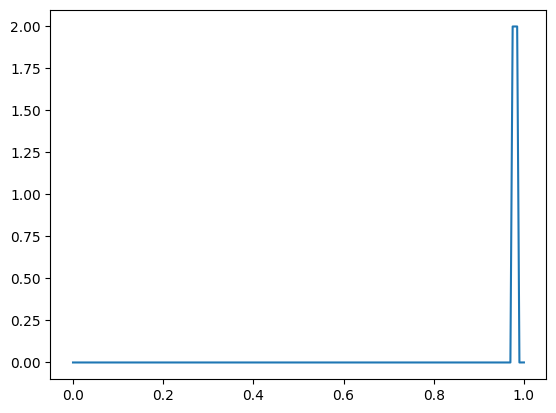

In [185]:
plt.plot(parameters, diffs)

Breakdown towards the end...?

#### Debug odd cases

In [187]:
odd_case = all_results[-6]

In [188]:
schmidt_values = [l[0] for l in odd_case]

In [189]:
schmidt_values

[np.float64(0.24999999956325444),
 np.float64(0.24999999924912938),
 np.float64(0.24999999924418614),
 np.float64(0.24999999893994804)]

In [191]:
[l[0] for l in all_results[-1]]

[np.float64(0.25000000000000094),
 np.float64(0.25000000000000033),
 np.float64(0.25),
 np.float64(0.24999999999999928)]

In [192]:
[l[0] for l in all_results[0]]

[np.float64(0.9999999999999992)]

In [193]:
[l[0] for l in all_results[110]]

[np.float64(0.2816749791250746),
 np.float64(0.24503952196094933),
 np.float64(0.2355754070474819),
 np.float64(0.23031894656956647)]

In [194]:
[l[0] for l in all_results[-5]]

[np.float64(0.24999999979888143),
 np.float64(0.24999999969873515),
 np.float64(0.24999999969747896),
 np.float64(0.24999999959984545)]

In [195]:
[l[0] for l in all_results[95]]

[np.float64(0.8117427922171673),
 np.float64(0.05211608441188502),
 np.float64(0.05151178376029794),
 np.float64(0.034345714650396195),
 np.float64(0.02305374598058335),
 np.float64(0.010831758171738783)]

In [196]:
[l[0] for l in all_results[105]]

[np.float64(0.33118629868732347),
 np.float64(0.22908017116439938),
 np.float64(0.21454016261836803),
 np.float64(0.209920248395445)]

In [192]:
[l[0] for l in all_results[0]]

[np.float64(0.9999999999999992)]

In [133]:
len(odd_case)

4

In [136]:
left_right_schmidt_values = [l[1] for l in odd_case]

In [137]:
left_right_schmidt_values

[array([2.50036542e-01, 2.50000060e-01, 2.49990874e-01, 2.49972520e-01,
        3.65399101e-05, 3.65361374e-05, 3.65327650e-05, 3.65260119e-05,
        4.29520497e-07, 4.29303729e-07, 4.29188054e-07, 4.29183849e-07,
        4.29127228e-07, 4.29117342e-07, 4.29114663e-07, 4.28982435e-07]),
 array([2.50082501e-01, 2.50036525e-01, 2.49981714e-01, 2.49899222e-01,
        3.65492985e-05, 3.65362047e-05, 3.65260064e-05, 3.65226395e-05,
        4.29483415e-07, 4.29324627e-07, 4.29219270e-07, 4.29209161e-07,
        4.29209161e-07, 4.29130289e-07, 4.29008738e-07, 4.28960765e-07]),
 array([2.50083980e-01, 2.50036525e-01, 2.49982426e-01, 2.49897032e-01,
        3.65501869e-05, 3.65361467e-05, 3.65260064e-05, 3.65218097e-05,
        4.29479772e-07, 4.29396781e-07, 4.29287262e-07, 4.29275060e-07,
        4.29095157e-07, 4.29073844e-07, 4.29021624e-07, 4.28916017e-07]),
 array([2.50036541e-01, 2.50000056e-01, 2.49990732e-01, 2.49972666e-01,
        3.65391437e-05, 3.65358057e-05, 3.65325289e-05, 3.

In [138]:
left_index_scores = [(l[2], l[3]) for l in odd_case]

In [142]:
np.round(np.array(left_index_scores), 3)

array([[ 1.   +0.j,  2.   +0.j],
       [-1.   -0.j,  1.483+0.j],
       [-1.   -0.j,  1.46 +0.j],
       [ 1.   +0.j,  2.   +0.j]])

In [140]:
right_index_scores = [(l[5], l[6]) for l in odd_case]

In [143]:
np.round(np.array(right_index_scores), 3)

array([[ 1.   -0.j,  2.   +0.j],
       [-1.   +0.j,  1.483+0.j],
       [-1.   +0.j,  1.46 +0.j],
       [ 1.   -0.j,  2.   +0.j]])

In [144]:
left_index_scores = [(l[2], l[3]) for l in all_results[-7]]

In [145]:
np.round(np.array(left_index_scores), 3)

array([[1.-0.j, 2.+0.j],
       [1.+0.j, 2.+0.j],
       [1.-0.j, 2.+0.j],
       [1.-0.j, 2.+0.j]])

In [146]:
right_index_scores = [(l[5], l[6]) for l in all_results[-7]]

In [147]:
np.round(np.array(right_index_scores), 3)

array([[1.+0.j, 2.+0.j],
       [1.-0.j, 2.+0.j],
       [1.+0.j, 2.+0.j],
       [1.+0.j, 2.+0.j]])

In [148]:
left_index_scores = [(l[2], l[3]) for l in all_results[-1]]

In [149]:
np.round(np.array(left_index_scores), 3)

array([[-1.   +0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j],
       [-1.   +0.j,  1.414+0.j]])

In [150]:
right_index_scores = [(l[5], l[6]) for l in all_results[-1]]

In [151]:
np.round(np.array(right_index_scores), 3)

array([[-1.   -0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j]])

In [152]:
left_index_scores = [(l[2], l[3]) for l in all_results[-2]]

In [153]:
np.round(np.array(left_index_scores), 3)

array([[-1.   +0.j,  1.414+0.j],
       [-1.   +0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j],
       [-1.   +0.j,  1.414+0.j]])

In [154]:
right_index_scores = [(l[5], l[6]) for l in all_results[-2]]

In [155]:
np.round(np.array(right_index_scores), 3)

array([[-1.   -0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j],
       [-1.   -0.j,  1.414+0.j]])

In [165]:
left_index_scores = [(l[2], l[3]) for l in all_results[-3]]

In [166]:
np.round(np.array(left_index_scores), 3)

array([[1.+0.j, 2.+0.j],
       [1.+0.j, 2.+0.j],
       [1.-0.j, 2.+0.j],
       [1.-0.j, 2.+0.j]])

In [167]:
right_index_scores = [(l[5], l[6]) for l in all_results[-3]]

In [168]:
np.round(np.array(right_index_scores), 3)

array([[1.-0.j, 2.+0.j],
       [1.-0.j, 2.+0.j],
       [1.+0.j, 2.+0.j],
       [1.+0.j, 2.+0.j]])

In [365]:
all_left_index_pairs = [
    (parameters[i], l1[2]) for i, l in enumerate(all_results)
    for l1 in l
]

In [366]:
all_left_index_paramaters, all_left_indices = list(zip(*all_left_indices))

ValueError: too many values to unpack (expected 2)

In [367]:
all_left_indices = np.real(all_left_indices)

ValueError: x and y must be the same size

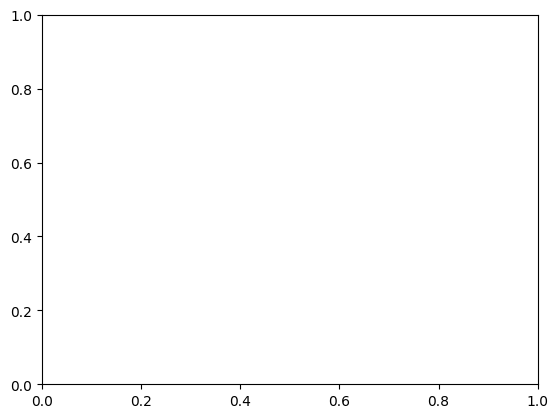

In [368]:
plt.scatter(all_left_index_paramaters, all_left_indices);

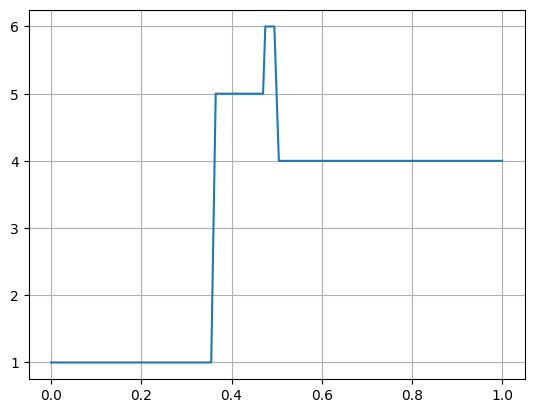

In [129]:
plt.plot(
    parameters,
    [len(l) for l in all_results]
)
plt.grid()

In [121]:
l = all_results[0]

In [122]:
sub_left_indices = np.real(np.array([l1[1] for l1 in l]))
diff = np.max(sub_left_indices) - np.min(sub_left_indices)
diffs.append(diff)

In [123]:
sub_left_indices

array([[1.00000000e+00, 1.50179345e-16, 1.24377497e-16, 9.38871438e-17,
        7.24748060e-17, 4.70731523e-17, 4.43320938e-17, 3.57216342e-17,
        3.12853787e-17, 2.30112952e-17, 1.89064772e-17, 1.50795525e-17,
        1.00395455e-17, 8.63862320e-18, 4.94367802e-18, 1.44192822e-18]])

## Defect operators from all purified/cut states.

In [288]:
psi = groundstates[160]

In [289]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [290]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [291]:
rho = basis.partial_trace(
    psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

In [292]:
eigenvalues, eigenvectors = np.linalg.eigh(rho)

Check we can rebuild rho correctly

In [294]:
rho_comparison = (
    eigenvectors
    @ np.diag(eigenvalues)
    @ eigenvectors.conj().T
)

In [295]:
np.linalg.norm(rho - rho_comparison)

np.float64(1.1262401284940209e-15)

Looks good.

In [296]:
rho_partial_conj = (
    eigenvectors
    @ np.diag(eigenvalues)
    @ eigenvectors.T
)

In [298]:
np_X_8 = multikron([np_X,]*8)

In [299]:
np_X_8.shape

(256, 256)

In [300]:
rho_partial_conj.shape

(256, 256)

In [301]:
sym_rho = (rho_partial_conj @ np_X_8)

(Is this equivalent to acting with symmetry_op?)

In [302]:
sym_rho = np.reshape(sym_rho, (2,)*16)

In [303]:
sym_rho.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [307]:
edm = sym_rho.copy()

In [308]:
for i in range(2, 6):
    edm = np.trace(edm, axis1=2, axis2=10-i)

In [309]:
edm.shape

(2, 2, 2, 2, 2, 2, 2, 2)

In [310]:
reshaped_edm = edm.reshape(4,4,4,4)
left_right_edm = np.transpose(reshaped_edm, axes=(0, 2, 1, 3))
reshaped_left_right_edm = left_right_edm.reshape(16, 16)

In [311]:
left_edm, left_right_schmidt_values, right_edm = (
    np.linalg.svd(reshaped_left_right_edm)
)

In [312]:
left_right_schmidt_values

array([0.10789281, 0.09948081, 0.09835651, 0.09176186, 0.05404224,
       0.05107387, 0.04908278, 0.04625534, 0.04490926, 0.04245344,
       0.04212146, 0.03970634, 0.02151008, 0.01977936, 0.01956794,
       0.01822273])

## Save results

In [81]:
all_results = np.concatenate(
    [np.array(parameters)[:, np.newaxis], results_array],
    axis=1
)

In [82]:
all_results.shape

(201, 4)

In [86]:
with open(r'../../make_plots/data/kitaev_chain_defect_operators/results.pkl', 'wb') as f:
    pickle.dump(all_results, f)

# Conclusion
Looks good.